In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler


def get_generator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.BatchNorm1d(output_dim),
        nn.ReLU(inplace=True),
    )

class GANs_Generator(nn.Module):
    def __init__(self, z_dim, im_dim, hidden_dim):
        super(GANs_Generator, self).__init__()
        self.generator = nn.Sequential(
            get_generator_block(z_dim, hidden_dim),
            get_generator_block(hidden_dim, hidden_dim * 2),
            get_generator_block(hidden_dim * 2, hidden_dim * 4),
            get_generator_block(hidden_dim * 4, hidden_dim * 8),
            nn.Linear(hidden_dim * 8, im_dim),
            nn.Sigmoid() 
        )
    def forward(self, noise):
        return self.generator(noise)

def get_discriminator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.LeakyReLU(0.2, inplace=True)        
    )

class GANs_Discriminator(nn.Module):
    def __init__(self, im_dim, hidden_dim):
        super(GANs_Discriminator, self).__init__()
        self.discriminator = nn.Sequential(
            get_discriminator_block(im_dim, hidden_dim * 4),
            get_discriminator_block(hidden_dim * 4, hidden_dim * 2),
            get_discriminator_block(hidden_dim * 2, hidden_dim),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, image):
        return self.discriminator(image)


def generate_GAN_Dataset(df, label_col="label_3", epochs=50, batch_size=512, z_dim=64, hidden_dim=64, lr=0.0002, random_state=42):
    
    np.random.seed(random_state)
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
        
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f" Device: {device}")

    id_cols = ["user_id", "course_id"]
    feature_cols = [col for col in df.columns if col not in id_cols + [label_col]]
    im_dim = len(feature_cols)

    global_scaler = StandardScaler()
    X_scaled_all = global_scaler.fit_transform(df[feature_cols].values)
    y_all = df[label_col].values

    unique_classes, counts = np.unique(y_all, return_counts=True)
    max_count = counts.max()

    synthetic_dfs = []

    for cls, count in zip(unique_classes, counts):
        samples_needed = max_count - count
        
        if samples_needed == 0:
            continue
            
        print(f"\nPhát hiện lớp thiểu số {cls}. Tiến hành huấn luyện GAN để sinh thêm {samples_needed} mẫu...")

        X_cls_raw = X_scaled_all[y_all == cls]
        
        local_mms = MinMaxScaler()
        X_cls_norm = local_mms.fit_transform(X_cls_raw)
        
        X_cls_tensor = torch.tensor(X_cls_norm, dtype=torch.float32).to(device)
        dataloader = DataLoader(X_cls_tensor, batch_size=batch_size, shuffle=True, drop_last=False)
        
        gen = GANs_Generator(z_dim, im_dim, hidden_dim).to(device)
        disc = GANs_Discriminator(im_dim, hidden_dim).to(device)
        
        gen_opt = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
        disc_opt = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))
        criterion = nn.BCEWithLogitsLoss()
        
        gen.train()
        disc.train()
        for epoch in range(epochs):
            for real_features in dataloader:
                cur_batch_size = len(real_features)
                
                # Huấn luyện Discriminator
                disc_opt.zero_grad()
                disc_real_pred = disc(real_features)
                disc_real_loss = criterion(disc_real_pred, torch.ones_like(disc_real_pred))
                
                noise = torch.randn(cur_batch_size, z_dim, device=device)
                fake_features = gen(noise)
                disc_fake_pred = disc(fake_features.detach())
                disc_fake_loss = criterion(disc_fake_pred, torch.zeros_like(disc_fake_pred))
                
                disc_loss = (disc_real_loss + disc_fake_loss) / 2
                disc_loss.backward()
                disc_opt.step()
                
                # Huấn luyện Generator
                gen_opt.zero_grad()
                disc_fake_pred_for_gen = disc(fake_features)
                gen_loss = criterion(disc_fake_pred_for_gen, torch.ones_like(disc_fake_pred_for_gen))
                gen_loss.backward()
                gen_opt.step()
                
        print(f" -> Hoàn thành {epochs} epochs cho lớp {cls}.")
        
        gen.eval()
        with torch.no_grad():
            final_noise = torch.randn(samples_needed, z_dim, device=device)
            generated_norm = gen(final_noise).cpu().numpy()
            
        generated_scaled = local_mms.inverse_transform(generated_norm)
        
        generated_original = global_scaler.inverse_transform(generated_scaled)
        
        df_syn = pd.DataFrame(generated_original, columns=feature_cols)
        df_syn[label_col] = cls
        
        for col in id_cols:
            if col in df.columns:
                original_ids = df[df[label_col] == cls][col].values
                df_syn[col] = np.random.choice(original_ids, size=len(df_syn))
                
        synthetic_dfs.append(df_syn)
        print(f" -> Đã tạo thành công {samples_needed} mẫu mới cho lớp {cls}.")

    if synthetic_dfs:
        df_final = pd.concat([df] + synthetic_dfs, axis=0, ignore_index=True)
        try:
            df_final[label_col] = df_final[label_col].astype(float).astype(int)
        except:
            pass

        df_final = df_final.sample(frac=1, random_state=random_state).reset_index(drop=True)
        return df_final
        
    return df.copy()

# Median imputation GAN

In [3]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Median/Median/train_median.parquet"
LABEL_COL = "label_3"

# Đọc file dữ liệu bảng gốc
df_median = pd.read_parquet(INPUT_FILE)

print(" Phân bố label trước GAN:")
print(df_median[LABEL_COL].value_counts().sort_index())

df_balanced = generate_GAN_Dataset(df_median, label_col=LABEL_COL, epochs=50, batch_size=512)

print("\n Phân bố label sau GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

 Phân bố label trước GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64
 Device: cuda

Phát hiện lớp thiểu số 0. Tiến hành huấn luyện GAN để sinh thêm 1851214 mẫu...
 -> Hoàn thành 50 epochs cho lớp 0.
 -> Đã tạo thành công 1851214 mẫu mới cho lớp 0.

Phát hiện lớp thiểu số 1. Tiến hành huấn luyện GAN để sinh thêm 1848158 mẫu...
 -> Hoàn thành 50 epochs cho lớp 1.
 -> Đã tạo thành công 1848158 mẫu mới cho lớp 1.

 Phân bố label sau GAN:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


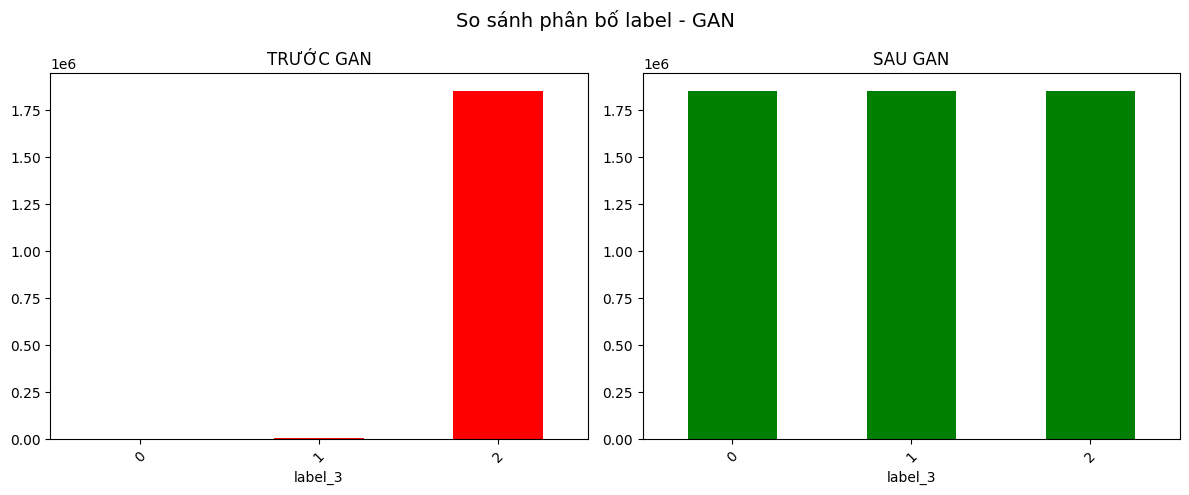

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_median[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
df_balanced.to_parquet('train_median_gan.parquet', index=False, engine='pyarrow', compression='snappy')

# Mean imputation GAN

In [6]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Mean/Mean/train_mean.parquet"
LABEL_COL = "label_3"

# Đọc file dữ liệu bảng gốc
df_mean = pd.read_parquet(INPUT_FILE)

print(" Phân bố label trước GAN:")
print(df_mean[LABEL_COL].value_counts().sort_index())

df_balanced = generate_GAN_Dataset(df_mean, label_col=LABEL_COL, epochs=50, batch_size=512)

print("\n Phân bố label sau GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

 Phân bố label trước GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64
 Device: cuda

Phát hiện lớp thiểu số 0. Tiến hành huấn luyện GAN để sinh thêm 1851214 mẫu...
 -> Hoàn thành 50 epochs cho lớp 0.
 -> Đã tạo thành công 1851214 mẫu mới cho lớp 0.

Phát hiện lớp thiểu số 1. Tiến hành huấn luyện GAN để sinh thêm 1848158 mẫu...
 -> Hoàn thành 50 epochs cho lớp 1.
 -> Đã tạo thành công 1848158 mẫu mới cho lớp 1.

 Phân bố label sau GAN:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


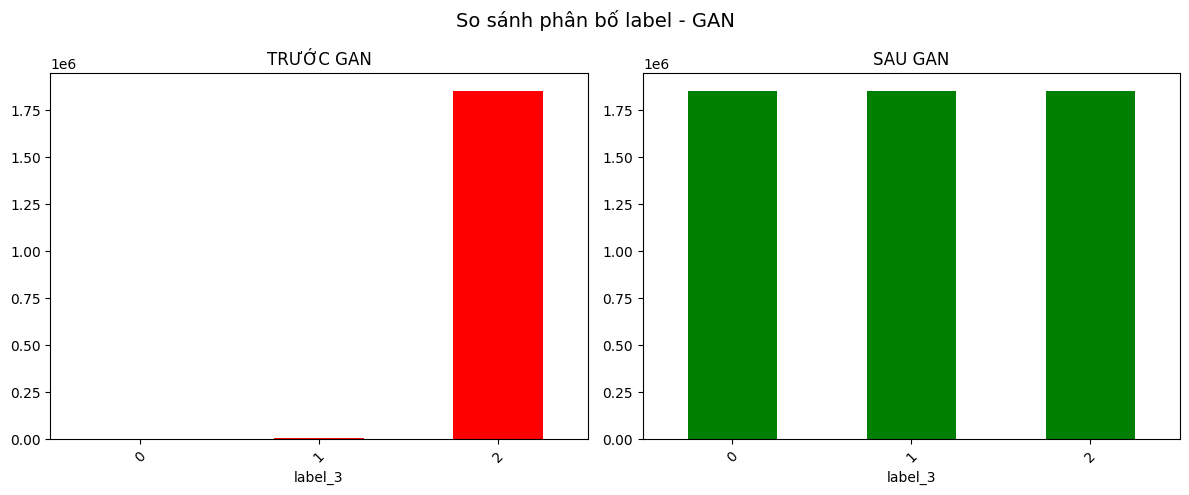

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_mean[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
df_balanced.to_parquet('train_mean_gan.parquet', index=False, engine='pyarrow', compression='snappy')

# Extra trees imputation GAN

In [9]:
INPUT_FILE = "/kaggle/input/datasets/anhtran10/lo-dataset/Extra_trees/Extra_trees/train_extra.parquet"
LABEL_COL = "label_3"

# Đọc file dữ liệu bảng gốc
df_extra = pd.read_parquet(INPUT_FILE)

print(" Phân bố label trước GAN:")
print(df_extra[LABEL_COL].value_counts().sort_index())

df_balanced = generate_GAN_Dataset(df_extra, label_col=LABEL_COL, epochs=50, batch_size=512)

print("\n Phân bố label sau GAN:")
print(df_balanced[LABEL_COL].value_counts().sort_index())

 Phân bố label trước GAN:
label_3
0       1783
1       4839
2    1852997
Name: count, dtype: int64
 Device: cuda

Phát hiện lớp thiểu số 0. Tiến hành huấn luyện GAN để sinh thêm 1851214 mẫu...
 -> Hoàn thành 50 epochs cho lớp 0.
 -> Đã tạo thành công 1851214 mẫu mới cho lớp 0.

Phát hiện lớp thiểu số 1. Tiến hành huấn luyện GAN để sinh thêm 1848158 mẫu...
 -> Hoàn thành 50 epochs cho lớp 1.
 -> Đã tạo thành công 1848158 mẫu mới cho lớp 1.

 Phân bố label sau GAN:
label_3
0    1852997
1    1852997
2    1852997
Name: count, dtype: int64


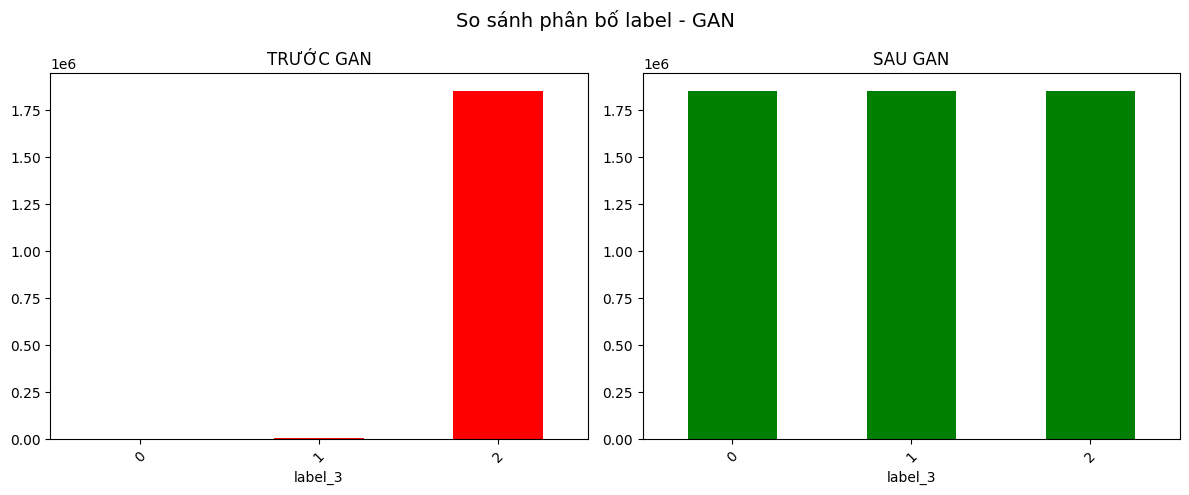

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df_extra[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="TRƯỚC GAN", color='red')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
df_balanced[LABEL_COL].value_counts().sort_index().plot(kind='bar', title="SAU GAN", color='green')
plt.xticks(rotation=45)

plt.suptitle("So sánh phân bố label - GAN", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
df_balanced.to_parquet('train_extra_gan.parquet', index=False, engine='pyarrow', compression='snappy')